<a href="https://colab.research.google.com/github/tiffanyviriya/multimedia-system-watermarking/blob/main/Tiffany_18224068_WM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[WM] shape=(32, 32), bits=1024, seed=2024
Upload your image:


Saving WhatsApp Image 2026-05-20 at 10.49.44.jpeg to WhatsApp Image 2026-05-20 at 10.49.44.jpeg
[IMG] 1280x960 | 19200 blocks | wm needs 1024 blocks


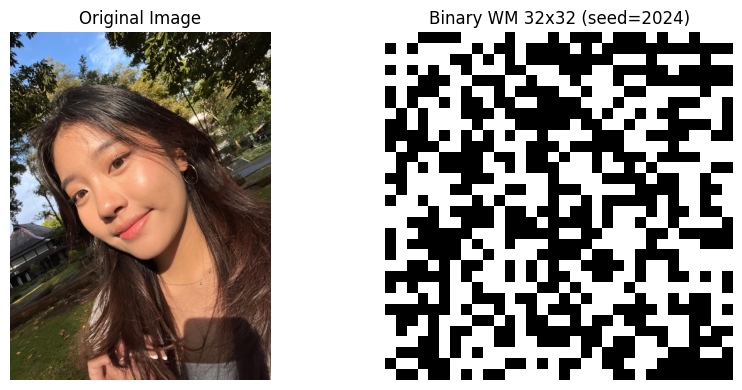

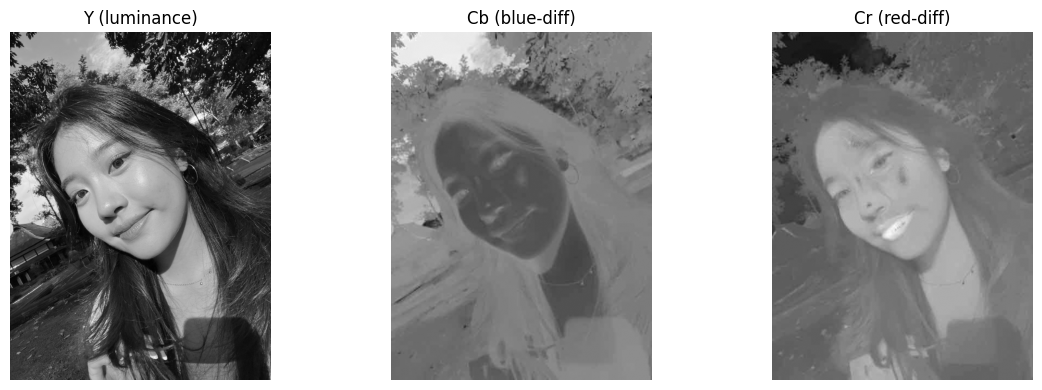


[EMBED] PSNR = 47.55 dB
[CHECK] BER (no compression) = 0.0000 (lossless)


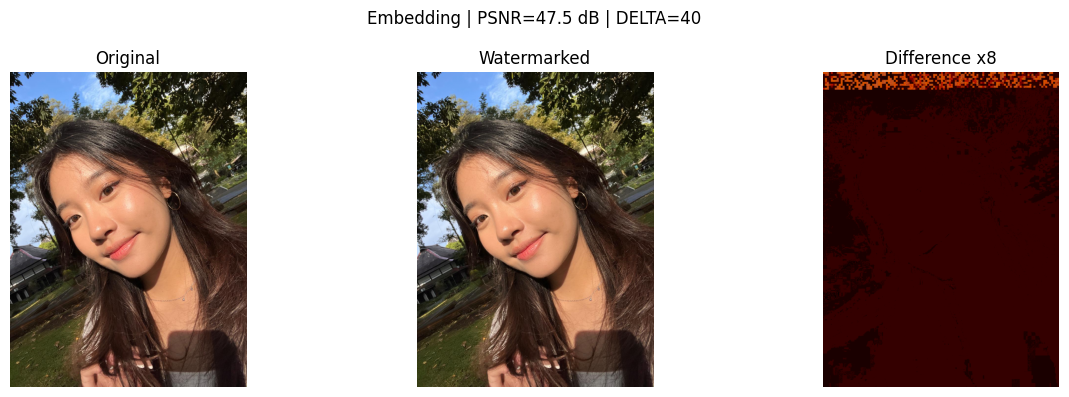

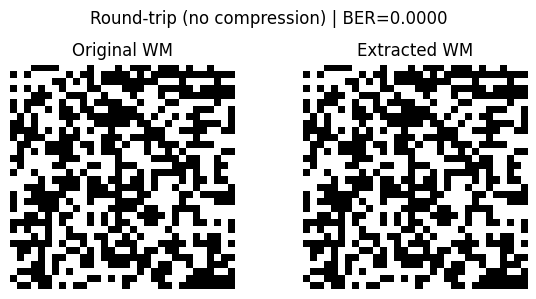

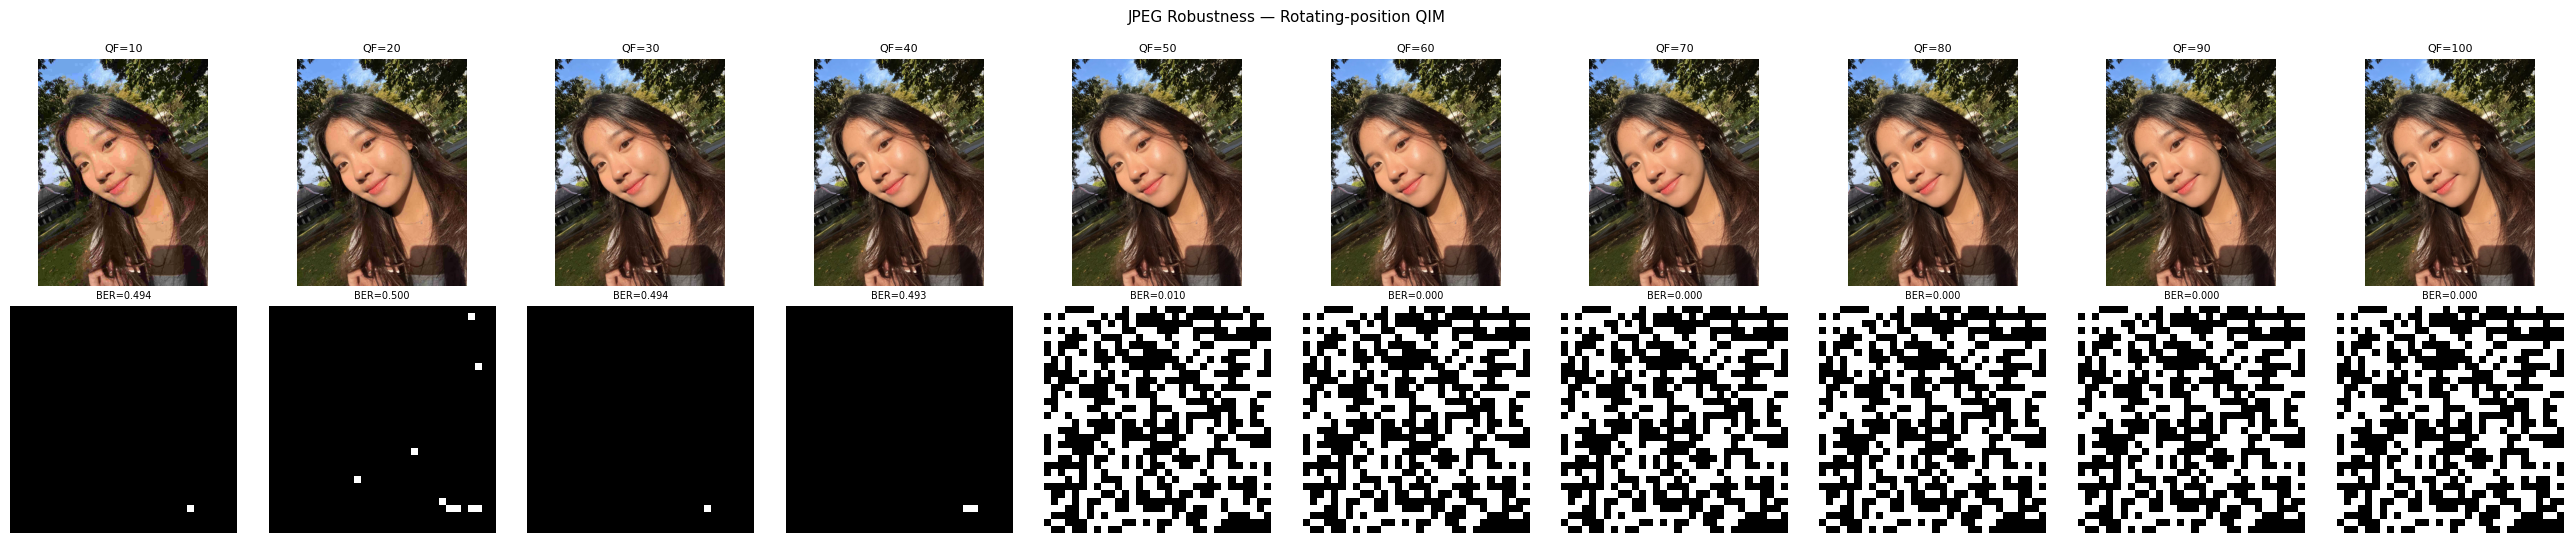


  QF       BER  Status
--------------------------------------
  10    0.4941  Gagal diekstrak
  20    0.5000  Gagal diekstrak
  30    0.4941  Gagal diekstrak
  40    0.4932  Gagal diekstrak
  50    0.0098  Dapat diekstrak
  60    0.0000  Dapat diekstrak (sempurna)
  70    0.0000  Dapat diekstrak (sempurna)
  80    0.0000  Dapat diekstrak (sempurna)
  90    0.0000  Dapat diekstrak (sempurna)
 100    0.0000  Dapat diekstrak (sempurna)

>>> Watermark tidak dapat diekstrak mulai dari QF = 10


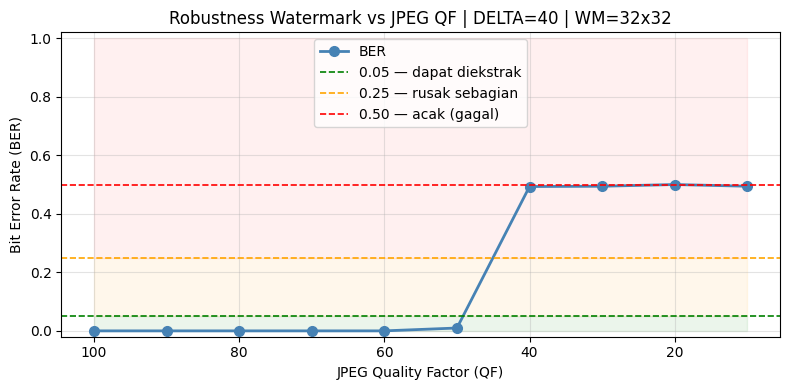

In [ ]:
# DCT Watermarking — Rotating Multi-Position QIM (no built-in DCT)

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# --- DCT / IDCT (manual) ---

_N = 8

def _build_dct_matrix(n):
    # Orthonormal DCT-II: M[k,i] = alpha(k) * cos(pi*(2i+1)*k / 2n)
    M = np.zeros((n, n), dtype=np.float64)
    for k in range(n):
        for i in range(n):
            M[k, i] = np.cos(np.pi * (2 * i + 1) * k / (2 * n))
    M[0, :] *= np.sqrt(1.0 / n)
    M[1:, :] *= np.sqrt(2.0 / n)
    return M

_DCT_M  = _build_dct_matrix(_N)
_IDCT_M = _DCT_M.T  # orthonormal → inverse = transpose

def dct2(block):
    return _DCT_M @ block.astype(np.float64) @ _IDCT_M

def idct2(D):
    return _IDCT_M @ D @ _DCT_M


# --- Colour space ---

def rgb_to_ycbcr(rgb):
    rgb = rgb.astype(np.float64)
    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    Y  =  0.299000 * R + 0.587000 * G + 0.114000 * B
    Cb = -0.168736 * R - 0.331264 * G + 0.500000 * B + 128.0
    Cr =  0.500000 * R - 0.418688 * G - 0.081312 * B + 128.0
    return np.stack([Y, Cb, Cr], axis=-1)

def ycbcr_to_rgb(ycc):
    Y, Cb, Cr = ycc[..., 0], ycc[..., 1] - 128.0, ycc[..., 2] - 128.0
    R = Y + 1.402000 * Cr
    G = Y - 0.344136 * Cb - 0.714136 * Cr
    B = Y + 1.772000 * Cb
    return np.clip(np.stack([R, G, B], axis=-1), 0, 255).astype(np.uint8)


# --- Stable binary watermark (fixed seed → same pattern every run) ---

WM_SEED = 2024
WM_ROWS, WM_COLS = 32, 32

WATERMARK = np.random.default_rng(WM_SEED).integers(0, 2, (WM_ROWS, WM_COLS), dtype=np.uint8)
print(f"[WM] shape={WATERMARK.shape}, bits={WATERMARK.size}, seed={WM_SEED}")


# --- Embedding config ---
# Rotate through 4 mid-frequency positions per bit instead of always using one spot;
# spreads watermark energy across the frequency plane for better robustness.

DELTA = 40  # quantisation step — larger = more robust, slightly more visible
POSITIONS = [(3, 4), (4, 3), (5, 2), (2, 5)]  # mid-frequency (row, col) pairs


# --- Embed / extract ---

def embed(Y_ch, wm, delta=DELTA, positions=POSITIONS):
    # QIM: quantise each block's rotating-position coefficient to match bit parity
    Y_out = Y_ch.copy().astype(np.float64)
    bits  = wm.flatten()
    h, w  = Y_ch.shape
    idx   = 0
    for row in range(0, h, 8):
        for col in range(0, w, 8):
            if idx >= len(bits):
                return Y_out
            D    = dct2(Y_out[row:row+8, col:col+8])
            r, c = positions[idx % len(positions)]
            coef = D[r, c]
            q    = round(coef / delta)
            if (q % 2) != int(bits[idx]):
                q = q + 1 if coef > q * delta else q - 1
            D[r, c] = q * delta
            Y_out[row:row+8, col:col+8] = idct2(D)
            idx += 1
    return Y_out

def extract(Y_ch, wm_shape, delta=DELTA, positions=POSITIONS):
    # Read parity of quantised coefficient at the same rotating position
    Y    = Y_ch.astype(np.float64)
    h, w = Y.shape
    bits = np.zeros(wm_shape[0] * wm_shape[1], dtype=np.uint8)
    idx  = 0
    for row in range(0, h, 8):
        for col in range(0, w, 8):
            if idx >= len(bits):
                return bits.reshape(wm_shape)
            D         = dct2(Y[row:row+8, col:col+8])
            r, c      = positions[idx % len(positions)]
            bits[idx] = int(round(D[r, c] / delta)) % 2
            idx += 1
    return bits.reshape(wm_shape)


# --- Manual JPEG simulation ---

Q_LUMA = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68, 109, 103,  77],
    [24, 35, 55, 64, 81, 104, 113,  92],
    [49, 64, 78, 87,103, 121, 120, 101],
    [72, 92, 95, 98,112, 100, 103,  99],
], dtype=np.float64)

Q_CHROMA = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
], dtype=np.float64)

def _scale_qtable(Q, qf):
    # Standard JPEG QF scaling: S = 5000/QF (qf<50) or 200-2*QF (qf>=50)
    qf = max(1, min(100, qf))
    S  = 5000 / qf if qf < 50 else 200 - 2 * qf
    Qs = np.floor((Q * S + 50) / 100)
    Qs[Qs < 1] = 1
    return Qs

def _jpeg_channel(ch, qf, Q):
    # Simulate quantise → dequantise on one channel
    Qs   = _scale_qtable(Q, qf)
    h, w = ch.shape
    out  = np.zeros_like(ch, dtype=np.float64)
    c    = ch.astype(np.float64) - 128.0
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            Dq = np.round(dct2(c[i:i+8, j:j+8]) / Qs) * Qs
            out[i:i+8, j:j+8] = idct2(Dq)
    return out + 128.0

def jpeg_simulate(rgb, qf):
    ycc = rgb_to_ycbcr(rgb)
    Yc  = _jpeg_channel(ycc[..., 0], qf, Q_LUMA)
    Cbc = _jpeg_channel(ycc[..., 1], qf, Q_CHROMA)
    Crc = _jpeg_channel(ycc[..., 2], qf, Q_CHROMA)
    return ycbcr_to_rgb(np.stack([Yc, Cbc, Crc], axis=-1)), Yc


# --- Metrics ---

def bit_error_rate(orig, ext):
    return float(np.mean(orig.flatten() != ext.flatten()))

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float(10 * np.log10(255.0 ** 2 / mse)) if mse > 0 else float('inf')


# --- Load image ---

if IN_COLAB:
    print("Upload your image:")
    uploaded   = files.upload()
    image_path = list(uploaded.keys())[0]
else:
    image_path = "test_image.jpg"  # change to your local path

img    = np.array(Image.open(image_path).convert('RGB'))
h0, w0 = img.shape[:2]
h, w   = (h0 // 8) * 8, (w0 // 8) * 8  # crop to 8-multiple
img    = img[:h, :w]

num_blocks = (h // 8) * (w // 8)
print(f"[IMG] {h}x{w} | {num_blocks} blocks | wm needs {WATERMARK.size} blocks")
assert num_blocks >= WATERMARK.size, \
    f"Image too small — needs >= {WATERMARK.size} blocks, has {num_blocks}."

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.imshow(img);                     ax1.set_title("Original Image");                              ax1.axis('off')
ax2.imshow(WATERMARK, cmap='gray');  ax2.set_title(f"Binary WM {WM_ROWS}x{WM_COLS} (seed={WM_SEED})"); ax2.axis('off')
plt.tight_layout(); plt.show()


# --- Embedding ---

ycc    = rgb_to_ycbcr(img)
Y_orig = ycc[..., 0].copy()
Cb, Cr = ycc[..., 1].copy(), ycc[..., 2].copy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ch, title in zip(axes, [Y_orig, Cb, Cr], ["Y (luminance)", "Cb (blue-diff)", "Cr (red-diff)"]):
    ax.imshow(ch, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

Y_wm      = embed(Y_orig, WATERMARK)
Y_wm_clip = np.clip(Y_wm, 0, 255)
img_wm    = ycbcr_to_rgb(np.stack([Y_wm_clip, Cb, Cr], axis=-1))

emb_psnr = psnr(img, img_wm)
print(f"\n[EMBED] PSNR = {emb_psnr:.2f} dB")

wm_rt  = extract(Y_wm_clip, WATERMARK.shape)
ber_rt = bit_error_rate(WATERMARK, wm_rt)
print(f"[CHECK] BER (no compression) = {ber_rt:.4f} ({'lossless' if ber_rt == 0 else 'embedding error'})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img);    axes[0].set_title("Original");    axes[0].axis('off')
axes[1].imshow(img_wm); axes[1].set_title("Watermarked"); axes[1].axis('off')
diff_vis = np.abs(img.astype(np.float64) - img_wm.astype(np.float64)).mean(axis=2)
axes[2].imshow(np.clip(diff_vis * 8, 0, 255).astype(np.uint8), cmap='hot')
axes[2].set_title("Difference x8"); axes[2].axis('off')
plt.suptitle(f"Embedding | PSNR={emb_psnr:.1f} dB | DELTA={DELTA}")
plt.tight_layout(); plt.show()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6, 3))
a1.imshow(WATERMARK, cmap='gray'); a1.set_title("Original WM");  a1.axis('off')
a2.imshow(wm_rt,     cmap='gray'); a2.set_title("Extracted WM"); a2.axis('off')
plt.suptitle(f"Round-trip (no compression) | BER={ber_rt:.4f}")
plt.tight_layout(); plt.show()


# --- Robustness test: QF = 10, 20, ..., 100 ---

QF_LIST = list(range(10, 101, 10))
results = []

n = len(QF_LIST)
fig_rob, axes_rob = plt.subplots(2, n, figsize=(2.6 * n, 5.5))

for k, qf in enumerate(QF_LIST):
    img_j, Y_j = jpeg_simulate(img_wm, qf)
    wm_ext      = extract(Y_j, WATERMARK.shape)
    b           = bit_error_rate(WATERMARK, wm_ext)
    results.append((qf, b))
    axes_rob[0, k].imshow(img_j);               axes_rob[0, k].set_title(f"QF={qf}", fontsize=8);  axes_rob[0, k].axis('off')
    axes_rob[1, k].imshow(wm_ext, cmap='gray');  axes_rob[1, k].set_title(f"BER={b:.3f}", fontsize=7); axes_rob[1, k].axis('off')

plt.suptitle("JPEG Robustness — Rotating-position QIM", fontsize=11)
plt.tight_layout(); plt.show()

# Summary table
print(f"\n{'QF':>4}  {'BER':>8}  Status")
print("-" * 38)
for qf, b in results:
    if   b == 0.0 : status = "Dapat diekstrak (sempurna)"
    elif b <  0.05: status = "Dapat diekstrak"
    elif b <  0.25: status = "Rusak sebagian"
    else          : status = "Gagal diekstrak"
    print(f"{qf:>4}  {b:>8.4f}  {status}")

# Explicitly show the first QF where extraction fails
fail_qf = next((qf for qf, b in results if b >= 0.25), None)
if fail_qf:
    print(f"\n>>> Watermark tidak dapat diekstrak mulai dari QF = {fail_qf}")
else:
    print("\n>>> Watermark berhasil diekstrak di semua nilai QF")

# BER vs QF plot
qf_vals, ber_vals = zip(*results)
plt.figure(figsize=(8, 4))
plt.plot(qf_vals, ber_vals, 'o-', color='steelblue', linewidth=2, markersize=7, label='BER')
plt.axhline(0.05, color='green',  linestyle='--', linewidth=1.2, label='0.05 — dapat diekstrak')
plt.axhline(0.25, color='orange', linestyle='--', linewidth=1.2, label='0.25 — rusak sebagian')
plt.axhline(0.50, color='red',    linestyle='--', linewidth=1.2, label='0.50 — acak (gagal)')
plt.fill_between(qf_vals, 0,    0.05, alpha=0.08, color='green')
plt.fill_between(qf_vals, 0.05, 0.25, alpha=0.08, color='orange')
plt.fill_between(qf_vals, 0.25, 1.00, alpha=0.06, color='red')
plt.xlabel("JPEG Quality Factor (QF)"); plt.ylabel("Bit Error Rate (BER)")
plt.title(f"Robustness Watermark vs JPEG QF | DELTA={DELTA} | WM={WM_ROWS}x{WM_COLS}")
plt.legend(); plt.grid(True, alpha=0.35)
plt.gca().invert_xaxis()  # heavy compression on left
plt.ylim(-0.02, 1.02)
plt.tight_layout(); plt.show()